# Практическое задание 1. Обучение полносвязной нейронной сети.

In [39]:
import os
import gzip
from typing import List, Tuple
from collections import OrderedDict, defaultdict
from matplotlib import pyplot as plt

import numpy as np
import torch
from torch import nn, optim
from torch.autograd import Function, gradcheck
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets
from torchvision import transforms

## 1. Загрузка данных (0 баллов)

Если вам требуется работать с каким-нибудь набором данных (dataset), то, прежде всего, проверьте, нет ли его среди встроенных наборов данных https://pytorch.org/vision/stable/datasets.html.

В текущем домашнем задании мы будем работать с набором данных FashionMNIST. Он присутствует в списке встроенных наборов данных, однако мы воспользуемся реализацией только для удобного и быстрого способа скачать наборы данных. Ниже предлагается реализовать собственный класс для считывания, обработки и упаковки данных.

In [2]:
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True
)

Воспользуемся функцией загрузки данных из репозитория наборов данных.

In [3]:
! ls data/FashionMNIST/raw

t10k-images-idx3-ubyte     train-images-idx3-ubyte
t10k-images-idx3-ubyte.gz  train-images-idx3-ubyte.gz
t10k-labels-idx1-ubyte     train-labels-idx1-ubyte
t10k-labels-idx1-ubyte.gz  train-labels-idx1-ubyte.gz


In [4]:
# https://github.com/zalandoresearch/fashion-mnist/blob/master/utils/mnist_reader.py


def load_mnist(path, kind="train"):
    """Load MNIST data from `path`"""
    labels_path = os.path.join(path, "%s-labels-idx1-ubyte.gz" % kind)
    images_path = os.path.join(path, "%s-images-idx3-ubyte.gz" % kind)

    with gzip.open(labels_path, "rb") as lbpath:
        labels = np.frombuffer(lbpath.read(), dtype=np.uint8, offset=8)

    with gzip.open(images_path, "rb") as imgpath:
        images = np.frombuffer(imgpath.read(), dtype=np.uint8, offset=16).reshape(
            len(labels), 784
        )

    return images, labels

Для удобства PyTorch предоставляет ряд базовых классов `Dataset, DataLoader`, от которых предлагается отнаследоваться при разработке пользовательских классов. Базовый класс `Dataset` используется для загрузки и обработки данных, класс `DataLoader` используется для управления процессом загрузки данных, позволяет в многопоточном режиме загружать данные и упаковывать их.
Эти вспомогательные классы находятся в модуле `torch.utils.data`.

При наследовании от класса `torch.utils.data.Dataset` требуется переопределить метод `__len__`, который возвращает количество примеров в наборе данных, а также метод `__getitem__`, который позволяет получить доступ к примеру из набора данных по индексу.

Реализуем класс для FasionMnist.

Элементами датасета должны являться пары '(np.array, int)', массив имеет размерность `(28, 28)`, тип элемента `np.float32`.

In [5]:
class FashionMnist(Dataset):
    def __init__(self, path, train=True, image_transform=None, label_transform=None):
        self.image_transform = image_transform
        self.label_transform = label_transform

        if train:
            self.images, self.labels = load_mnist(os.path.join(path, "raw"))
        else:
            self.images, self.labels = load_mnist(
                os.path.join(path, "raw"), kind="t10k"
            )

    def __len__(self):
        return self.images.shape[0]

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        if self.image_transform is not None:
            image = self.image_transform(image)
        if self.label_transform is not None:
            label = self.label_transform(label)
        return image, label


In [6]:
test_dataset = FashionMnist("data/FashionMNIST", train=False)
train_dataset = FashionMnist("data/FashionMNIST")

Визуализируйте случайные элементы набора данных.

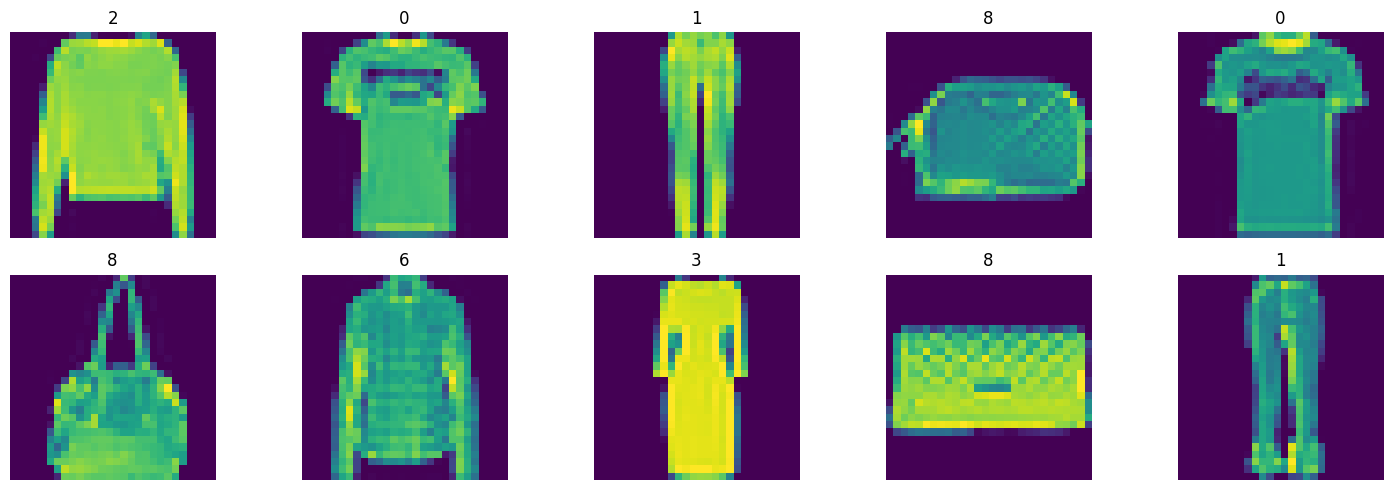

In [7]:
random_ids = np.random.choice(len(train_dataset), 10)
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 5))
axes = axes.flatten()

for i, idx in enumerate(random_ids):
    img, label = train_dataset[idx]
    axes[i].imshow(img.reshape(28, 28))
    axes[i].set_title(f"{label}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()
plt.close()

В конструктор `Dataset` можно передать объект `torchvision.transforms`, который позволяет преобразовать исходные данные. Преобразование `torchvision.transforms.ToTensor` позволяет преобразоать данные из типа `PIL Image` и `numpy.float32` в тип `torch.float32`

Реализуйте собственную поддержку преобразований в `FashionMnist`. Проверьте, что приведение типов работает корректно.

In [8]:
class ToTensor(nn.Module):
    def __init__(self, images: bool = False):
        super().__init__()
        self.images = images

    def forward(self, x: torch.Tensor):
        x = torch.tensor(x)
        if self.images:
            return x.to(torch.float32) / 255
        return x.to(torch.int64)


image_transform = transforms.Compose(transforms=[ToTensor(images=True)])
label_transform = transforms.Compose(transforms=[ToTensor()])

test_dataset = FashionMnist(
    "data/FashionMNIST",
    train=False,
    image_transform=image_transform,
    label_transform=label_transform,
)
train_dataset = FashionMnist(
    "data/FashionMNIST",
    image_transform=image_transform,
    label_transform=label_transform,
)

In [9]:
print(f"The type of the data is {type(test_dataset[0][0])}")

The type of the data is <class 'torch.Tensor'>


Элементы набора данных могут быть объединены в пакеты (batch) явно и неявно. Если данные могут быть сконкатенированы или обЪединены каким-нибудь тривиальным способом, то можно не передавать никаких дополнительных парамертов в `torch.utils.data.Dataloader`.

In [10]:
test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=True)
batch = next(iter(test_dataloader))

In [11]:
print(f"The length of the batch is {len(batch)}")
print(f"The shape of the batch[0] is {batch[0].shape}")

The length of the batch is 2
The shape of the batch[0] is torch.Size([16, 784])


Однако, если наша структура данных не позволяет нам использовать объединение по умолчанию, то можно написать собственную функцию, которая будет пакетировать данные.

Реализуйте функцию, преобразующую последовательность элементов массива в пакет (batch).

In [12]:
def collate(batch):
    imgs = []
    labels = []
    for img, label in batch:
        imgs.append(img)
        labels.append(label)

    return torch.stack(imgs), torch.stack(labels)

Убедитесть, что все работает корректно.

In [13]:
test_dataloader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=True,
    collate_fn=collate,
)
train_dataloader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    collate_fn=collate,
)
batch = next(iter(test_dataloader))

In [14]:
print(f"The length of the batch is {len(batch)}")
print(f"The shape of the batch[0] is {batch[0].shape}")

The length of the batch is 2
The shape of the batch[0] is torch.Size([16, 784])


## 2. Реализация модулей нейронной сети (15 баллов)

В этом разделе мы полностью реализуем модули для полносвязанной сети.

Для начала нам понадобится реализовать прямой и обратный проход через слои.

Наши слои будут соответствовать следующему интерфейсу (на примере "тождественного" слоя):

Сначала, мы реализуем функцию и её градиент.

In [15]:
class IdentityFunction(Function):
    """
    We can implement our own custom autograd Functions by subclassing
    torch.autograd.Function and implementing the forward and backward passes
    which operate on Tensors.
    """
    @staticmethod
    def forward(ctx, input):
        """
        In the forward pass we receive a Tensor containing the input and return
        a Tensor containing the output. ctx is a context object that can be used
        to stash information for backward computation. You can cache arbitrary
        objects for use in the backward pass using the ctx.save_for_backward method.
        """
        return input

    @staticmethod
    def backward(ctx, grad_output):
        """
        In the backward pass we receive a Tensor containing the gradient of the loss
        with respect to the output, and we need to compute the gradient of the loss
        with respect to the input.
        """
        return grad_output

Разработанную функцию обернем классом `IdentityLayer`, все слои в `PyTorch` должны быть наследниками базового класса `nn.Module()`


In [16]:
class IdentityLayer(nn.Module):
    def __init__(self):
        # An identity layer does nothing
        super().__init__()
        self.identity = IdentityFunction.apply

    def forward(self, inp):
        # An identity layer just returns whatever it gets as input.
        return self.identity(inp)


### 2.1 Функция активации ReLU (1 балл)
Для начала реализуем функцию активации, слой нелинейности `ReLU(x) = max(x, 0)`. Параметров у слоя нет. Метод `forward` должен вернуть результат поэлементного применения `ReLU` к входному массиву, метод `backward` - градиент функции потерь по входу слоя. В нуле будем считать производную равной 0. Обратите внимание, что при обратном проходе могут понадобиться величины, посчитанные во время прямого прохода, поэтому их стоит сохранить в `ctx`.

In [17]:
class ReLUFunction(Function):
    @staticmethod
    def forward(ctx, input: torch.Tensor):
        mask = input > 0
        ctx.save_for_backward(mask)
        return torch.clamp(input, min=0)

    @staticmethod
    def backward(ctx, grad_output: torch.Tensor):
        (mask,) = ctx.saved_tensors
        grad_input = grad_output * mask.to(grad_output.dtype)
        return grad_input


In [18]:
class ReLU(nn.Module):
    def __init__(self):
        super().__init__()
        self.fn = ReLUFunction.apply

    def forward(self, input: torch.Tensor):
        return self.fn(input)

Не забываем после реализации функции проверить градиент, испльзуя функцию `gradcheck`.

In [19]:
relu = ReLU()
x = torch.tensor([-2, -1, 1, 2], dtype=torch.float64, requires_grad=True)

assert gradcheck(relu, x)

In [20]:
our_relu = ReLU()
torch_relu = nn.ReLU()

assert torch.norm(torch_relu(x.float()) - our_relu(x)) < 1e-5

### 2.2 Линейный слой (linear, fully-connected) (3 балла)
Далее реализуем полносвязный слой без нелинейности. У слоя два набора параметра: матрица весов (weights) и вектор смещения (bias).

In [21]:
class LinearFunction(Function):
    @staticmethod
    def forward(ctx, inp: torch.Tensor, weight: torch.Tensor, bias: torch.Tensor):
        ctx.save_for_backward(inp, weight)
        return inp @ weight.T + bias[None]

    @staticmethod
    def backward(ctx, grad_output: torch.Tensor):
        inp, weight = ctx.saved_tensors
        grad_input = grad_output @ weight
        grad_weight = grad_output.T @ inp
        grad_bias = grad_output.sum(0)
        return grad_input, grad_weight, grad_bias

In [119]:
class Linear(nn.Module):
    def __init__(self, input_units: int, output_units: int):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(output_units, input_units, requires_grad=True) / np.sqrt(input_units))
        self.bias = nn.Parameter(torch.zeros(output_units, requires_grad=True))
        self.fn = LinearFunction.apply

    def load_state_dict(self, state_dict: OrderedDict[str, torch.Tensor], strict: bool = True, assign: bool = False):
        self.weight = state_dict["weight"]
        self.bias = state_dict["bias"]
        return self

    def forward(self, inp: torch.Tensor):
        return self.fn(inp, self.weight, self.bias)


Проверим градиент, а также сравним с работой нашего модуля с имплементированным в `PyTorch`.

Проверка градиента:

In [120]:
linear = Linear(3, 4)
linear.double()
x = torch.randn(1, 3, requires_grad=True, dtype=torch.float64)

assert gradcheck(linear, x)

Сравнение с `PyTorch`.

In [121]:
weight = nn.Parameter(torch.randn(4, 3, requires_grad=True))
bias = nn.Parameter(torch.randn(4, requires_grad=True))

torch_linear = nn.Linear(3, 4)
our_linear = Linear(3, 4)

state_dict = OrderedDict([("weight", weight), ("bias", bias)])
torch_linear.load_state_dict(state_dict)
our_linear.load_state_dict(state_dict)

x = torch.randn(1, 3)

assert torch.allclose(torch_linear(x), our_linear(x))

### 2.3 LogSoftmax (Log + Softmax) (4 балла)

Для решения задачи многоклассовой классификации обычно используют `softmax` в качестве нелинейности на последнем слое, чтобы получить "оценку" вероятности классов для каждого объекта:$$\hat y = softmax(x)  = \bigl \{\frac {exp(x_i)}{\sum_j exp(x_j)} \bigr \}_{i=1}^K, \quad K - \text{число классов}$$В этом случае удобно оптимизировать логарифм правдоподобия:$$L(y, \hat y) = -\sum_{i=1}^K y_i \log \hat y_i \rightarrow \min,$$где $y_i=1$, если объект принадлежит $i$-му классу, и 0 иначе. Записанная в таком виде, эта функция потерь совпадает с выражением для кросс-энтропии. Очевидно, что ее также можно переписать через индексацию, если через $y_i$ обозначить класс данного объекта:$$L(y, \hat y) = - \log \hat y_{y_i} \rightarrow \min$$В таком виде ее удобно реализовывать.

Реализуйте слой `LogSoftmax` (без параметров). Метод `forward` должен вычислять логарифм от `softmax`, а метод `backward` - пропускать градиенты. В общем случае в промежуточных вычислениях `backward` получится трехмерный тензор, однако для нашей конкретной функции потерь все вычисления можно реализовать в матричном виде. Поэтому мы будем предполагать, что аргумент `grad_output` - это матрица, у которой в каждой строке только одно ненулевое значение (не обязательно единица).

Для полного балла нужна имплементация с `Log-Sum-Exp trick`.

In [137]:
class LogSoftmaxFunction(Function):
    @staticmethod
    def forward(ctx, inp: torch.Tensor):
        c = torch.max(inp, dim=-1, keepdim=True).values
        logsumexp = c + torch.log(torch.sum(torch.exp(inp - c), dim=-1, keepdim=True))

        log_softmax = inp - logsumexp
        softmax = torch.exp(log_softmax)
        ctx.save_for_backward(softmax)

        return log_softmax

    @staticmethod
    def backward(ctx, grad_output: torch.Tensor):
        (softmax,) = ctx.saved_tensors

        grad_input = grad_output - softmax * grad_output.sum(dim=-1, keepdim=True)
        
        return grad_input

In [138]:
class LogSoftmax(nn.Module):
    def __init__(self):
        super().__init__()
        self.fn = LogSoftmaxFunction.apply

    def forward(self, input: torch.Tensor):
        return self.fn(input)


Проверка градиентов.

In [139]:
fn = LogSoftmax()
x = torch.randn(1, 5, requires_grad=True).to(torch.float64)

assert gradcheck(fn, x)

### 2.4 Dropout (2 балла)
Реализуйте слой Dropout.

In [140]:
class DropoutFunction(Function):
    @staticmethod
    def forward(ctx, inp: torch.Tensor, p: float):
        mask = torch.bernoulli(torch.ones_like(inp) * (1 - p))
        multiplier = torch.tensor(1 / (1 - p) if p < 1 else 0)
        ctx.save_for_backward(mask, multiplier)

        return inp * mask * multiplier

    @staticmethod
    def backward(ctx, grad_output: torch.Tensor):
        (mask, multiplier) = ctx.saved_tensors

        return grad_output * mask * multiplier, None


In [141]:
class Dropout(nn.Module):
    def __init__(self, p):
        super().__init__()
        self.fn = DropoutFunction.apply
        self.p = p

    def forward(self, input):
        if self.training:
            return self.fn(input, self.p)
        
        return input

In [142]:
x = torch.randn(1, 5)

assert torch.allclose(Dropout(p=1.0)(x), torch.zeros_like(x))
assert torch.allclose(Dropout(p=0.0)(x), x)

### 2.5 CrossEntropy (5 баллов)

При решении задачи многоклассовой классификации мы будет использовать в качестве функции потерь **кроссэнтропию, совместимую с `LogSoftmax` активацией**. 

Реализуйте эту функцию потерь. В разделе 2.3 приведены полезные формулы.

In [143]:
class CrossEntropyFunction(Function):
    @staticmethod
    def forward(ctx, activations: torch.Tensor, target: torch.LongTensor):
        ctx.save_for_backward(activations, target)
        gathered = torch.gather(activations, dim=-1, index=target[:, None])

        return torch.mean(-gathered)

    @staticmethod
    def backward(ctx, grad_output: torch.Tensor):
        (activations, target) = ctx.saved_tensors
        grad_input = torch.zeros_like(activations)
        batch_size = activations.size(0)
        grad_values = -grad_output.expand(batch_size, 1) / batch_size
        grad_input.scatter_(-1, target[:, None], grad_values)

        return grad_input, None


In [144]:
class CrossEntropy(nn.Module):
    def __init__(self):
        super().__init__()
        self.fn = CrossEntropyFunction.apply

    def forward(self, activations: torch.Tensor, target: torch.Tensor):
        return self.fn(activations, target)


Проверка градиентов.

In [145]:
ce = CrossEntropy()

x = torch.randn(5, 5, requires_grad=True).to(torch.float64)
activations = torch.log_softmax(x, dim=-1)
target = torch.randint(0, 5, (5,))

assert gradcheck(ce, (activations, target))

## 3. Сборка и обучение нейронной сети (5 баллов)

Реализуйте из ваших блоков персептрон и обучите его, залоггировав итоговый лосс и метрику на валидационной выборке. **(1 балл)**

Подсказка: вытягиваем картинку в вектор с помощью [nn.Flatten](https://pytorch.org/docs/stable/generated/torch.nn.Flatten.html)

In [146]:
class Network(nn.Module):
    def __init__(self, input_size=28 * 28, hidden_layers_size=32, num_layers=5, num_classes=10, activation=None):
        super().__init__()

        if activation is None:
            activation = nn.ReLU

        self.network = nn.Sequential(
            Linear(input_size, hidden_layers_size),
            *[
                nn.Sequential(
                    activation(),
                    Linear(hidden_layers_size, hidden_layers_size),
                )
                for _ in range(num_layers - 2)
            ],
            activation(),
            Linear(hidden_layers_size, num_classes),
            LogSoftmax(),
        )

    def forward(self, inp: torch.Tensor):
        return self.network(inp)

    def predict(self, inp: torch.Tensor):
        return torch.argmax(self.forward(inp), dim=-1)


Ниже приведены функции, реализующие обучение нейронной сети. В данном задании их предлагается просто переиспользовать.

In [147]:
class EmptyContext:
    def __enter__(self):
        pass

    def __exit__(self, *args):
        pass


def accuracy(model_labels: torch.Tensor, labels: torch.Tensor):
    return torch.sum((model_labels == labels).float())


def perform_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: str,
    optimizer: optim.Optimizer | None = None,
):
    is_train = optimizer is not None
    model = model.to(device)
    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0
    total_acc = 0
    num_batches = 0
    num_samples = 0

    with EmptyContext() if is_train else torch.no_grad():
        for batch_data, batch_labels in loader:
            batch_data = batch_data.to(device)
            batch_size = batch_data.shape[0]
            batch_labels = batch_labels.to(device)
            model_labels = model(batch_data)
            model_prediction = model.predict(batch_data)
            new_loss = criterion(model_labels, batch_labels)
            if is_train:
                optimizer.zero_grad()
                new_loss.backward()
                optimizer.step()

            one_batch_loss = new_loss.item()
            one_batch_acc = accuracy(model_prediction, batch_labels).item()

            total_loss += one_batch_loss
            total_acc += one_batch_acc
            num_batches += 1
            num_samples += batch_size

    return (total_loss / num_batches, total_acc / num_samples)


def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    device: str,
    num_epochs: int,
) -> Tuple[List[float], List[float], List[float], List[float]]:
    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []

    for _ in range(num_epochs):
        train_loss, train_acc = perform_epoch(
            model=model, loader=train_loader, criterion=criterion, device=device, optimizer=optimizer
        )
        val_loss, val_acc = perform_epoch(model=model, loader=val_loader, criterion=criterion, device=device)

        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
    
    return train_losses, train_accs, val_losses, val_accs

Теперь обучим нашу нейронную сеть. В данном разделе будем использовать оптимизатор `Adam` с параметрами по умолчанию.

In [148]:
model = Network()
optimizer = optim.Adam(model.parameters())
criterion = CrossEntropy()

train_dataloader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True,
    collate_fn=collate,
)
test_dataloader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False,
    collate_fn=collate,
)

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

model.to(device)

for epoch in range(10):
    loss, acc = perform_epoch(model, train_dataloader, criterion, optimizer=optimizer, device=device)
    print(f"Epoch - {epoch} : loss {loss}, accuracy {acc}")
    print(f"Current learning rate: {optimizer.param_groups[0]['lr']}")

Epoch - 0 : loss 0.8605746853858867, accuracy 0.7000666666666666
Current learning rate: 0.001
Epoch - 1 : loss 0.4738857534337551, accuracy 0.8339833333333333
Current learning rate: 0.001
Epoch - 2 : loss 0.4245930708469228, accuracy 0.84785
Current learning rate: 0.001
Epoch - 3 : loss 0.39645520410639173, accuracy 0.8574833333333334
Current learning rate: 0.001
Epoch - 4 : loss 0.37683977712976174, accuracy 0.8644833333333334
Current learning rate: 0.001
Epoch - 5 : loss 0.36768142669758896, accuracy 0.86805
Current learning rate: 0.001
Epoch - 6 : loss 0.3565132278711238, accuracy 0.8709166666666667
Current learning rate: 0.001
Epoch - 7 : loss 0.34228272140026095, accuracy 0.8756666666666667
Current learning rate: 0.001
Epoch - 8 : loss 0.33257185740673795, accuracy 0.8797166666666667
Current learning rate: 0.001
Epoch - 9 : loss 0.323478168819813, accuracy 0.8825833333333334
Current learning rate: 0.001


Дальше **(4 балла)**:
- Проведите эксперименты с числом слоев.
- Постройте графики зависимости качества модели на тренировочной и тестовой выборках от числа слоев. Для получения статистически значимых результатов повторите эксперименты несколько раз.
- Сделайте выводы.

Training Loop для выполнения этой части задания можно и нужно улучшать, в том числе, добавляя более продвинутое логгирование эксперимента.

In [149]:
depths = [2, 3, 4, 5, 6, 7]
num_runs = 5
metrics = defaultdict(lambda: defaultdict(list))

for depth in depths:
    for run in range(num_runs):
        print(f"Depth: {depth}, Run: {run}")
        model = Network(num_layers=depth)
        optimizer = optim.Adam(model.parameters())
        criterion = CrossEntropy()

        train_losses, train_accs, val_losses, val_accs = train_model(
            model=model,
            train_loader=train_dataloader,
            val_loader=test_dataloader,
            criterion=criterion,
            optimizer=optimizer,
            device=device,
            num_epochs=10,
        )
        metrics[depth]["last_val_acc"].append(val_accs[-1])
        metrics[depth]["max_val_acc"].append(max(val_accs))
        metrics[depth]["last_val_loss"].append(val_losses[-1])
        metrics[depth]["min_val_loss"].append(min(val_losses))
        metrics[depth]["last_train_loss"].append(train_losses[-1])
        metrics[depth]["min_train_loss"].append(min(train_losses))

Depth: 2, Run: 0
Depth: 2, Run: 1
Depth: 2, Run: 2
Depth: 2, Run: 3
Depth: 2, Run: 4
Depth: 3, Run: 0
Depth: 3, Run: 1
Depth: 3, Run: 2
Depth: 3, Run: 3
Depth: 3, Run: 4
Depth: 4, Run: 0
Depth: 4, Run: 1
Depth: 4, Run: 2
Depth: 4, Run: 3
Depth: 4, Run: 4
Depth: 5, Run: 0
Depth: 5, Run: 1
Depth: 5, Run: 2
Depth: 5, Run: 3
Depth: 5, Run: 4
Depth: 6, Run: 0
Depth: 6, Run: 1
Depth: 6, Run: 2
Depth: 6, Run: 3
Depth: 6, Run: 4
Depth: 7, Run: 0
Depth: 7, Run: 1
Depth: 7, Run: 2
Depth: 7, Run: 3
Depth: 7, Run: 4


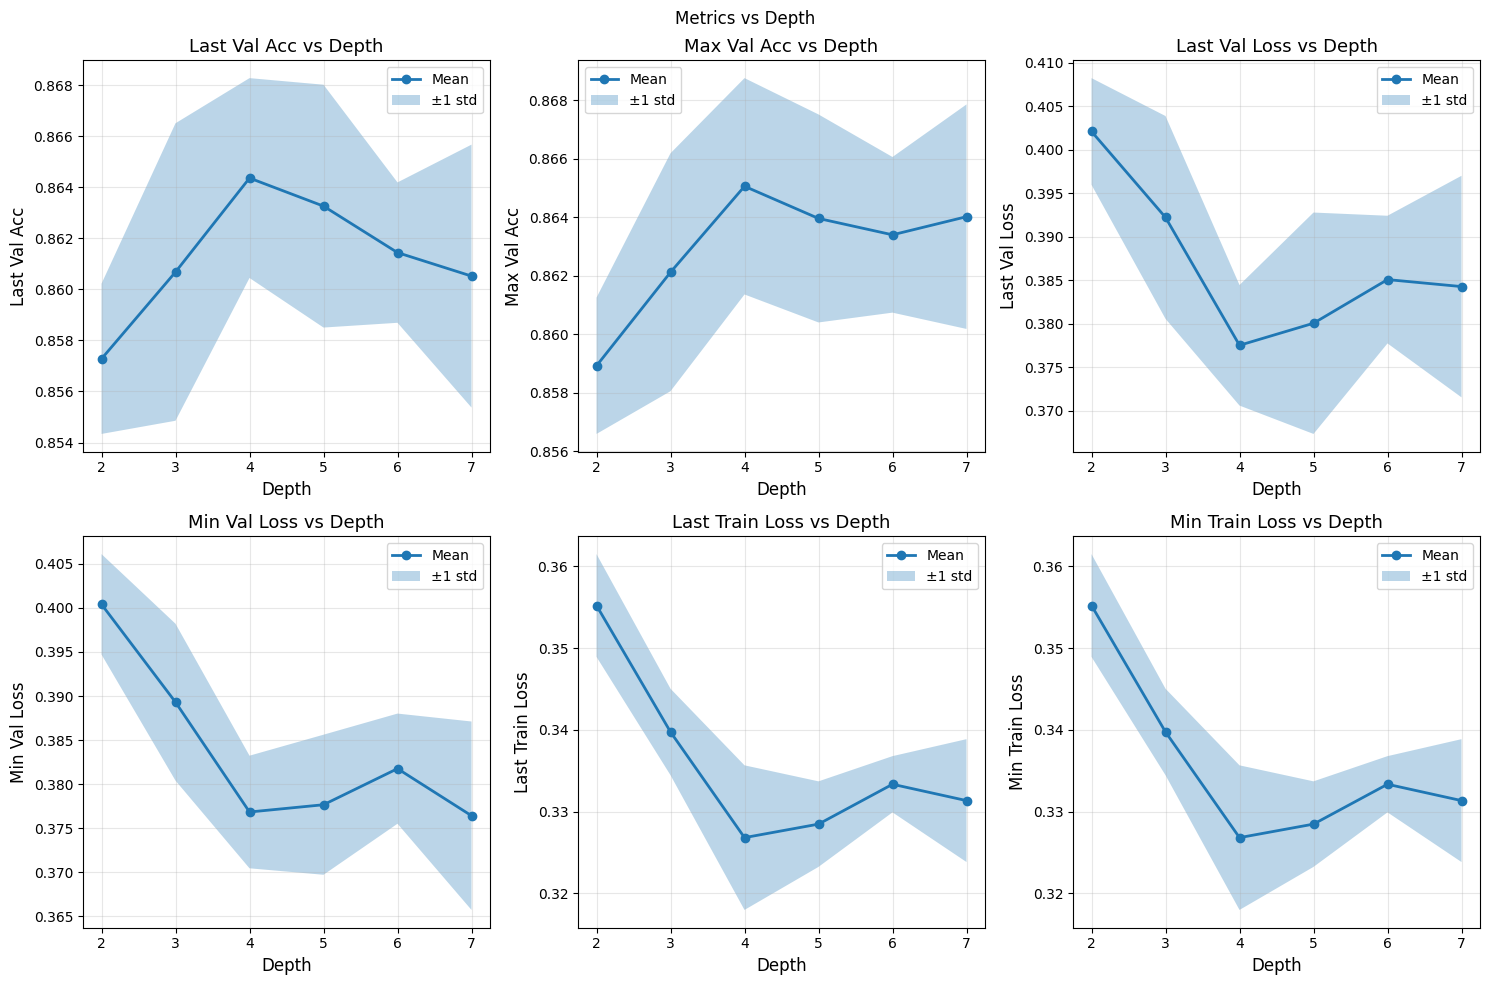

In [153]:
metric_names = ["last_val_acc", "max_val_acc", "last_val_loss", "min_val_loss", "last_train_loss", "min_train_loss"]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, metric_name in enumerate(metric_names):
    ax = axes[idx]

    depths_list = sorted(metrics.keys())
    means = [np.mean(metrics[depth][metric_name]) for depth in depths_list]
    stds = [np.std(metrics[depth][metric_name]) for depth in depths_list]

    ax.plot(depths_list, means, marker="o", linewidth=2, label="Mean")

    ax.fill_between(
        depths_list, np.array(means) - np.array(stds), np.array(means) + np.array(stds), alpha=0.3, label="±1 std"
    )

    ax.set_xlabel("Depth", fontsize=12)
    ax.set_ylabel(metric_name.replace("_", " ").title(), fontsize=12)
    ax.set_title(f"{metric_name.replace('_', ' ').title()} vs Depth", fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.suptitle("Metrics vs Depth")
plt.tight_layout()
plt.show()

## 4. Бонусная часть.

### 4.1 Реализация метода оптимизации (3 + 3 балла).
Реализуйте сами метод оптимизации  для рассмотренной выше архитектуры. Вы можете выбрать произвольный метод от градиентного спуска до современных вариантов. Продемонстрируйте правильную работу метода оптимизации, сравните его работы с Adam.

**Дополнительные баллы** вы получите, если метод будет уникален среди сдавших задание.

In [154]:
def newtonschulz5(G, steps=5, eps=1e-7):
    assert G.ndim == 2
    orig_dtype = G.dtype
    a, b, c = (3.4445, -4.7750, 2.0315)
    X = G.bfloat16()
    X /= X.norm() + eps
    if G.size(0) > G.size(1):
        X = X.T
    for _ in range(steps):
        A = X @ X.T
        B = b * A + c * A @ A
        X = a * X + B @ X
    if G.size(0) > G.size(1):
        X = X.T
    return X.to(orig_dtype)


class Muon(optim.Optimizer):
    def __init__(self, params, lr: float = 2e-2, beta: float = 0.95, weight_decay: float = 0.01, ns_steps: int = 5):
        defaults = dict(lr=lr, beta=beta, weight_decay=weight_decay, ns_steps=ns_steps)
        super(Muon, self).__init__(params, defaults)

    def __setstate__(self, state):
        super(Muon, self).__setstate__(state)

    @torch.no_grad()
    def step(self, closure=None):
        for group in self.param_groups:
            lr = group["lr"]
            beta = group["beta"]
            weight_decay = group["weight_decay"]
            ns_steps = group["ns_steps"]
            for p in group["params"]:
                if p.grad is None:
                    continue
                p.mul_(1 - lr * weight_decay)

                state = self.state[p]

                if "momentum" not in state:
                    state["momentum"] = torch.zeros_like(p)

                g = p.grad
                m = state["momentum"]

                if p.ndim == 2:
                    g = newtonschulz5(g, ns_steps)

                m.lerp_(g, 1 - beta)
                g.lerp_(m, beta)
                p.add_(g, alpha=-lr)


In [155]:
metrics_muon = defaultdict(list)

for run in range(num_runs):
    network = Network(num_layers=4)
    optimizer = Muon(network.parameters())
    criterion = CrossEntropy()

    train_losses, train_accs, val_losses, val_accs = train_model(
        model=network,
        train_loader=train_dataloader,
        val_loader=test_dataloader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        num_epochs=10,
    )

    metrics_muon["last_val_acc"].append(val_accs[-1])
    metrics_muon["max_val_acc"].append(max(val_accs))
    metrics_muon["last_val_loss"].append(val_losses[-1])
    metrics_muon["min_val_loss"].append(min(val_losses))
    metrics_muon["last_train_loss"].append(train_losses[-1])
    metrics_muon["min_train_loss"].append(min(train_losses))


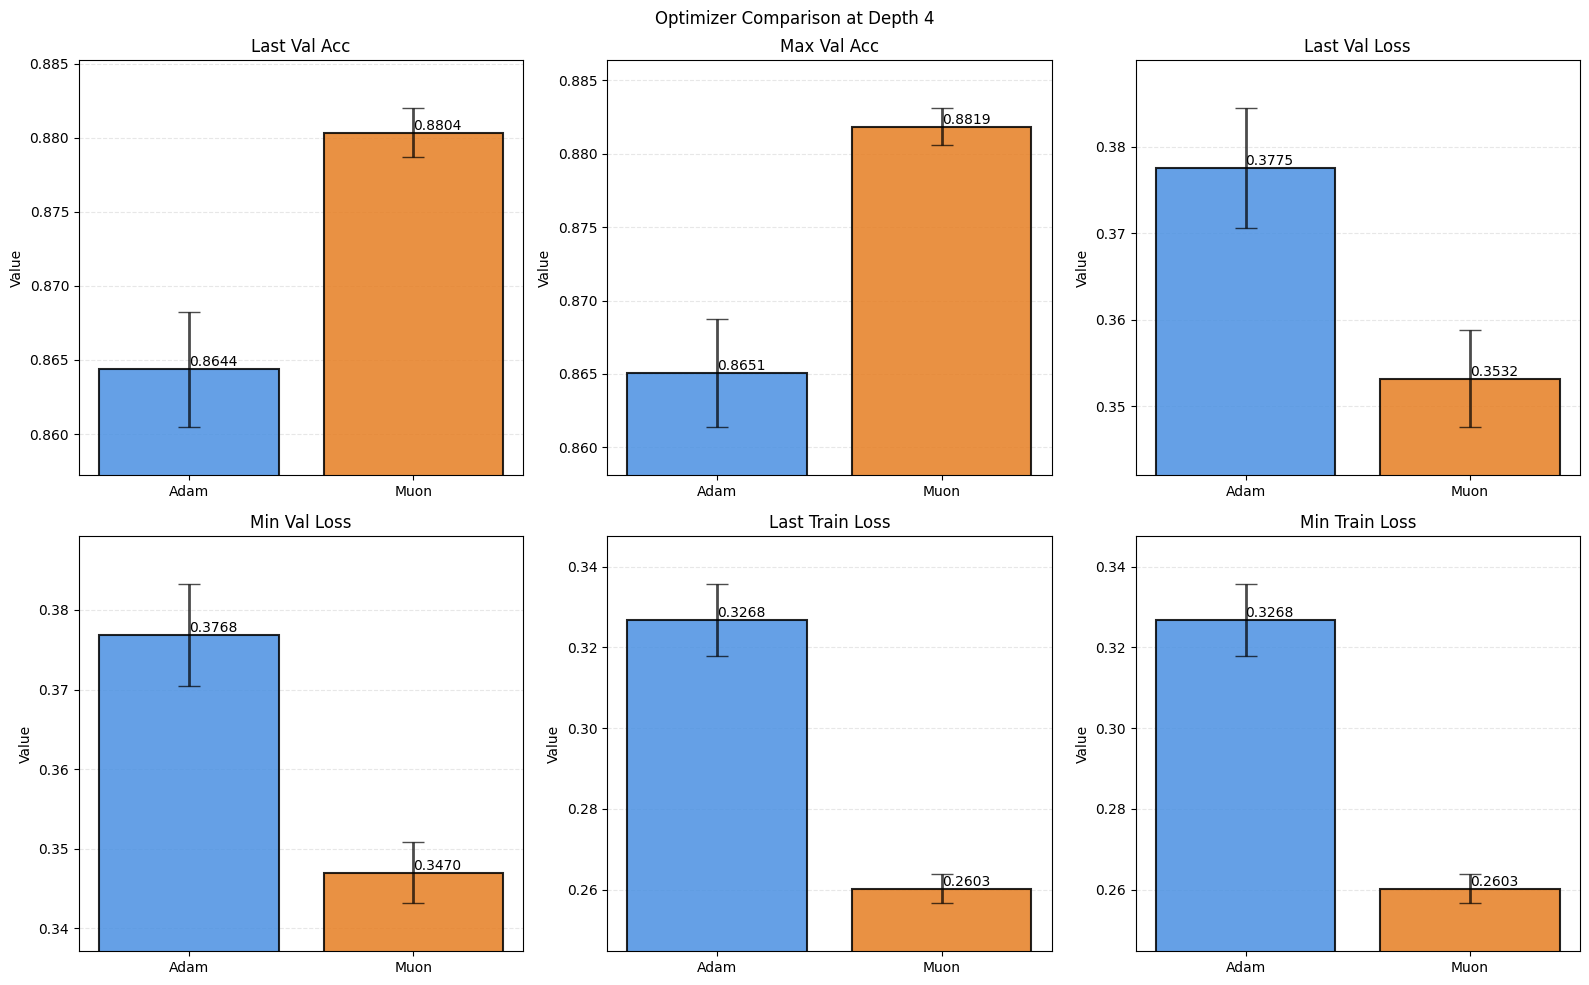

In [172]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, metric_name in enumerate(metric_names):
    ax = axes[idx]

    original_mean = np.mean(metrics[4][metric_name])
    original_std = np.std(metrics[4][metric_name])

    muon_mean = np.mean(metrics_muon[metric_name])
    muon_std = np.std(metrics_muon[metric_name])

    bars = ax.bar(
        ["Adam", "Muon"],
        [original_mean, muon_mean],
        yerr=[original_std, muon_std],
        alpha=0.85,
        capsize=8,
        color=["#4A90E2", "#E67E22"],
        edgecolor="black",
        linewidth=1.5,
        error_kw={"linewidth": 2, "ecolor": "black", "alpha": 0.7},
    )

    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2.0,
            height,
            f"{height:.4f}",
            ha="left",
            va="bottom",
        )

    all_values = [
        original_mean - original_std,
        original_mean + original_std,
        muon_mean - muon_std,
        muon_mean + muon_std,
    ]
    y_min = min(all_values)
    y_max = max(all_values)
    y_range = y_max - y_min

    padding = y_range * 0.15
    ax.set_ylim(y_min - padding, y_max + padding)

    ax.set_ylabel("Value")
    ax.set_title(metric_name.replace("_", " ").title())
    ax.grid(True, alpha=0.3, axis="y", linestyle="--")
    ax.set_axisbelow(True)


plt.suptitle("Optimizer Comparison at Depth 4")
plt.tight_layout()
plt.show()

### 4.2 Реализация современной функции активации (2 + 2 балла).
Реализуйте одну из активаций, предложенных на лекции или в статье. Например, `Hardswish`. Сравните сеть с вашей активацией и с `ReLU`.

**Дополнительные баллы** вы получите, если функция будет уникальна среди сдавших задание.

In [166]:
class GCUFunction(Function):
    @staticmethod
    def forward(ctx, input: torch.Tensor):
        ctx.save_for_backward(input)

        return torch.cos(input) * input

    @staticmethod
    def backward(ctx, grad_output: torch.Tensor):
        (input,) = ctx.saved_tensors

        return grad_output * (-torch.sin(input) * input + torch.cos(input))


class GCU(nn.Module):
    def __init__(self):
        super().__init__()
        self.fn = GCUFunction.apply

    def forward(self, input: torch.Tensor):
        return self.fn(input)


In [168]:
x = torch.randn(1, 5, dtype=torch.float64, requires_grad=True)
gcu = GCU()

assert gradcheck(gcu, x)

In [169]:
metrics_gcu = defaultdict(list)

for run in range(num_runs):
    network = Network(num_layers=4, activation=GCU)
    optimizer = optim.Adam(network.parameters())
    criterion = CrossEntropy()

    train_losses, train_accs, val_losses, val_accs = train_model(
        model=network,
        train_loader=train_dataloader,
        val_loader=test_dataloader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        num_epochs=10,
    )

    metrics_gcu["last_val_acc"].append(val_accs[-1])
    metrics_gcu["max_val_acc"].append(max(val_accs))
    metrics_gcu["last_val_loss"].append(val_losses[-1])
    metrics_gcu["min_val_loss"].append(min(val_losses))
    metrics_gcu["last_train_loss"].append(train_losses[-1])
    metrics_gcu["min_train_loss"].append(min(train_losses))


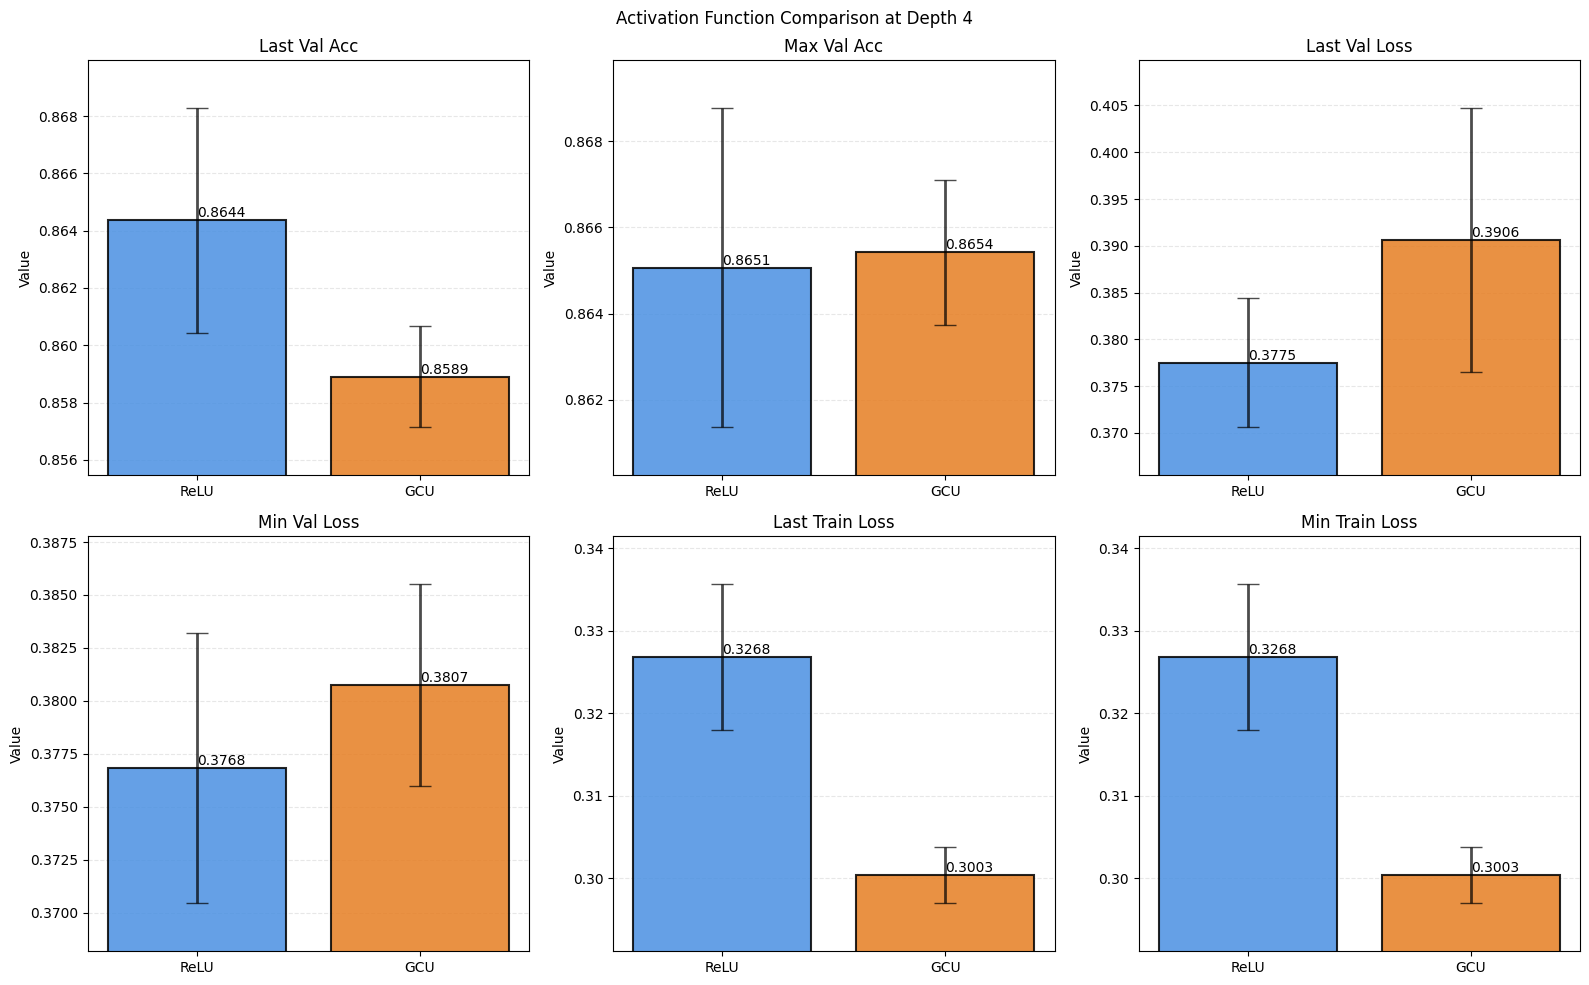

In [173]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, metric_name in enumerate(metric_names):
    ax = axes[idx]

    original_mean = np.mean(metrics[4][metric_name])
    original_std = np.std(metrics[4][metric_name])

    gcu_mean = np.mean(metrics_gcu[metric_name])
    gcu_std = np.std(metrics_gcu[metric_name])

    bars = ax.bar(
        ["ReLU", "GCU"],
        [original_mean, gcu_mean],
        yerr=[original_std, gcu_std],
        alpha=0.85,
        capsize=8,
        color=["#4A90E2", "#E67E22"],
        edgecolor="black",
        linewidth=1.5,
        error_kw={"linewidth": 2, "ecolor": "black", "alpha": 0.7},
    )

    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2.0,
            height,
            f"{height:.4f}",
            ha="left",
            va="bottom",
        )

    all_values = [
        original_mean - original_std,
        original_mean + original_std,
        gcu_mean - gcu_std,
        gcu_mean + gcu_std,
    ]
    y_min = min(all_values)
    y_max = max(all_values)
    y_range = y_max - y_min

    padding = y_range * 0.15
    ax.set_ylim(y_min - padding, y_max + padding)

    ax.set_ylabel("Value")
    ax.set_title(metric_name.replace("_", " ").title())
    ax.grid(True, alpha=0.3, axis="y", linestyle="--")
    ax.set_axisbelow(True)


plt.suptitle("Activation Function Comparison at Depth 4")
plt.tight_layout()
plt.show()